# Project: Online Payments Fraud Detection

This project builds an end-to-end machine learning system for detecting fraudulent online payment transactions. 
Leveraging transaction and account data, it focuses on accurate classification and supports real-time inference and risk-based decision-making.

Two tree-based models, Random Forest and XGBoost, were trained and evaluated. The Random Forest model achieved a ROC-AUC of 0.9996 and a PR-AUC of 0.9975, slightly outperforming XGBoost (ROC-AUC 0.9977, PR-AUC 0.9817), and was therefore selected as the final model.

To translate model outputs into actionable decisions, a decision threshold was optimized based on validation performance, resulting in an optimal threshold of 0.73. This threshold enables the conversion of predicted probabilities into binary fraud classifications and downstream risk actions. After threshold tuning, the model demonstrates near-perfect classification performance, with precision, recall, and F1-score all approaching 1.00, indicating strong separability between fraudulent and non-fraudulent transactions in the dataset.

Feature importance analysis shows that the model primarily relies on balance consistency and transaction anomaly signals. In particular, features capturing discrepancies between expected and actual account balances, changes in the sender’s balance during transactions, and indicators of balance inconsistency play a dominant role. These patterns align with domain intuition, as fraudulent transactions often involve irregular or inconsistent balance updates.

Finally, the system outputs both a fraud probability score and a corresponding decision based on predefined thresholds, which can be mapped to actions such as ALLOW, REVIEW, or BLOCK. The full pipeline is integrated into a FastAPI service and a Streamlit dashboard, enabling real-time inference, monitoring, and interactive inspection of model behavior.

<a id="workflow"></a>
## Workflow Overview
1. [Data Understanding & Preparation](#data-understanding--preparation)
    - EDA
    - Feature Engineering
    - Train-Test Split
2. [Model Development](#model-development)
   - Model Training
   - Model Evaluation (ROC Curve, Confusion Matrix)
   - Best Model Selection 
3. [Model Optimization](#post-model-optimization)
   - Threshold Tuning (Post-model Optimization)
4. [Model Interpretability](#model-interpretability)
   - Feature Importance 
5. [End-to-End Pipeline Execution](#end-to-end-pipeline-execution)
   - Full system run to validate end-to-end workflow 
6. [Experiment Tracking](#experiment-tracking)
   - MLflow Logging
7. [Inference System](#inference-system)
   - Real-time Prediction
   - Risk Decision Layer (ALLOW / REVIEW / BLOCK)
8. [Model Monitoring & System Observability](#model-monitoring--system-observability)
   - Drift Detection (KS Test)
   - System Monitoring & Logging
9. [Model Deployment](#model-deployment)
   - FastAPI Service
10. [Visualization & Monitoring Dashboard](#visualization--monitoring-dashboard)
    - Streamlit Monitoring Dashboard
    - Fraud Monitoring Dashboard (Observability Layer)

### Dataset & key features
    step: represents a unit of time where 1 step equals 1 hour
    type: type of online transaction
    amount: the amount of the transaction
    nameOrig: customer starting the transaction
    oldbalanceOrg: balance before the transaction
    newbalanceOrig: balance after the transaction
    nameDest: recipient of the transaction
    oldbalanceDest: initial balance of recipient before the transaction
    newbalanceDest: the new balance of recipient after the transaction
    isFraud: fraud transaction

You can get the dataset on Kaggle: 
https://www.kaggle.com/datasets/rupakroy/online-payments-fraud-detection-dataset

<a id="data-prep"></a>
## 1. Data Understanding & Preparation 

In [1]:
import os
import joblib
import random
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from xgboost import XGBClassifier
from xgboost import plot_importance
from scipy.stats import gaussian_kde
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, average_precision_score

In [2]:
def load_data(path):
    data = pd.read_csv(path)
    return data

### 1.1 EDA (Exploratory Data Analysis)

#### EDA Summary

In [3]:
def eda_summary(df):
    summary = {}

    summary["shape"] = df.shape
    summary["missing_values"] = df.isna().sum()
    summary["describe"] = df.describe()
    summary["dtypes"] = df.dtypes

    print("Shape:", summary["shape"])
    print("\nMissing Values:\n", summary["missing_values"])
    print("\nDescribe:\n", summary["describe"])

    return summary

#### EDA Visualization

##### How many unique users were involved in fraud?

In [4]:
def plot_fraud_distribution(df):
    plt.figure(figsize=(5,4))

    fraud_counts = df['isFraud'].value_counts()

    labels = ['Not Fraud (0)', 'Fraud (1)']
    colors = sns.color_palette('Set2')[1:3]

    plt.pie(
        fraud_counts,
        labels=labels,
        autopct='%1.2f%%',
        startangle=90,
        colors=colors)

    plt.title("Fraud vs Non-Fraud Distribution")
    plt.axis("equal")
    plt.show()

##### What kinds of transactions are most common?¶

In [5]:
def plot_transaction_type_distribution(df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # -----------------------------
    # 1️. Overall transaction type
    # -----------------------------
    sns.countplot(x="type", data=df, palette="Set2", ax=axes[0])
    axes[0].set_title("Transaction Type Distribution")
    axes[0].set_xlabel("Type")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].grid(False)

    # -----------------------------
    # 2. Fraud by transaction type
    # -----------------------------
    fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)

    sns.barplot(
        x=fraud_by_type.index,
        y=fraud_by_type.values,
        palette="Set2",
        ax=axes[1])

    axes[1].set_title("Fraud Rate by Transaction Type")
    axes[1].set_xlabel("Type")
    axes[1].set_ylabel("Fraud Rate")
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].grid(False)

    plt.tight_layout()
    plt.show()

##### At what times does fraud most often occur?

In [6]:
def plot_step_distribution(df):
    plt.figure(figsize=(8,5))

    sns.histplot(df["step"], bins=50, kde=False, color="skyblue")

    plt.title("Transaction Step Distribution")
    plt.xlabel("Step")
    plt.ylabel("Count")

    plt.grid(False)
    plt.tight_layout()
    plt.show()

##### What is the relation between old and new balances for different transaction types?

In [7]:
def plot_balance_scatter(df):
    colors = sns.color_palette("Set2", 2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.scatterplot(
        x="oldbalanceOrg", y="newbalanceOrig", data=df, hue="isFraud", alpha=0.4, palette={0: colors[0], 1: colors[1]}, ax=axes[0])

    axes[0].set_title("Origin Balance Change")

    sns.scatterplot(
        x="oldbalanceDest", y="newbalanceDest", data=df, hue="isFraud", alpha=0.4, palette={0: colors[1], 1: colors[0]}, ax=axes[1])

    axes[1].set_title("Destination Balance Change")

    plt.tight_layout()
    plt.show()

##### How transaction amount relates to balance change?

In [8]:
def plot_amount_balance_relation(df):
    colors = sns.color_palette("Set2", 2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    df["Difference_Orig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
    df["Difference_Dest"] = df["newbalanceDest"] - df["oldbalanceDest"]

    sns.scatterplot(
        x="amount",
        y="Difference_Orig",
        data=df,
        hue="isFraud",
        alpha=0.4,
        palette={0: colors[0], 1: colors[1]},
        ax=axes[0])

    axes[0].set_title("Amount vs Origin Balance Difference")

    sns.scatterplot(
        x="amount",
        y="Difference_Dest",
        data=df,
        hue="isFraud",
        alpha=0.4,
        palette={0: colors[0], 1: colors[1]},
        ax=axes[1])

    axes[1].set_title("Amount vs Destination Balance Difference")

    plt.tight_layout()
    plt.show()

##### How do old and new balances relate across different transaction types and fraud status?

In [9]:
def plot_log_balance_analysis(df):
    df = df.copy()

    df["log_oldbalanceOrg"] = np.log1p(df["oldbalanceOrg"])
    df["log_newbalanceOrig"] = np.log1p(df["newbalanceOrig"])
    df["log_oldbalanceDest"] = np.log1p(df["oldbalanceDest"])
    df["log_newbalanceDest"] = np.log1p(df["newbalanceDest"])

    features = [
        "log_oldbalanceOrg",
        "log_newbalanceOrig",
        "log_oldbalanceDest",
        "log_newbalanceDest"]

    plt.figure(figsize=(16,10))

    for i, col in enumerate(features, 1):
        plt.subplot(2, 2, i)
        sns.boxplot(x="type", y=col, data=df)
        plt.title(f"{col} by Transaction Type")
        plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

##### Top 10 High-Activity Accounts (Senders & Receivers)

In [10]:
def plot_top_entity_fraud_count(df, entity_col, top_n=10):
    """
    Analyze fraud count among top active entities (senders/receivers)
    """

    # Identify most active entities
    top_entities = df[entity_col].value_counts().head(top_n).index

    # Filter dataset
    subset = df[df[entity_col].isin(top_entities)]

    # Compute fraud counts
    fraud_count = subset.groupby(entity_col)["isFraud"].sum().sort_values(ascending=False)

    # Plot results
    plt.figure(figsize=(8, 4))
    sns.barplot(
        x=fraud_count.values,
        y=fraud_count.index,
        hue=fraud_count.index,
        palette="Reds",
        legend=False)

    plt.title(f"Fraud Count among Top {top_n} {entity_col}")
    plt.xlabel("Fraud Count")
    plt.ylabel(entity_col)

    plt.tight_layout()
    plt.show()

##### Entity-Level Fraud Exposure among High-Activity Accounts

In [11]:
def plot_top_entity_fraud_analysis(df, entity_col, top_n=10):
    """
    Analyze fraud rate among top active entities (senders/receivers)
    """

    # 1. Identify top active entities based on transaction frequency
    top_entities = df[entity_col].value_counts().head(top_n).index

    # 2. Filter dataset to include only top entities
    subset = df[df[entity_col].isin(top_entities)]

    # 3. Compute fraud rate for each entity
    fraud_rate = subset.groupby(entity_col)["isFraud"].mean().sort_values(ascending=False)

    # 4. Plot fraud rate distribution
    plt.figure(figsize=(8, 4))
    sns.barplot(
        x=fraud_rate.values,
        y=fraud_rate.index,
        palette="Reds")

    plt.title(f"Fraud Rate among Top {top_n} {entity_col}")
    plt.xlabel("Fraud Rate")
    plt.ylabel(entity_col)

    plt.tight_layout()
    plt.show()

##### Feature Correlation Heatmap

In [12]:
def plot_correlation_heatmap(df, cols=None):
    
    # Plot correlation heatmap for numeric features
    # 1. Select numeric features
    if cols is None:
        numeric_df = df.select_dtypes(include=['int64', 'float64'])
    else:
        numeric_df = df[cols]

    # 2. Compute correlation matrix
    corr = numeric_df.corr()

    # 3. Plot heatmap
    plt.figure(figsize=(10, 6))

    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

    plt.title("Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()

### 1.2 Feature engineering

In [13]:
def engineer_features(df):
    df = df.copy()

    # -----------------------------
    # Balance features
    # -----------------------------
    #Balance differences
    df["Difference_Orig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
    df["Difference_Dest"] = df["newbalanceDest"] - df["oldbalanceDest"]
    
    # Balance consistency errors
    df["error_balance_orig"] = (df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"])
    df["error_balance_dest"] = (df["newbalanceDest"] - df["oldbalanceDest"] - df["amount"])
     
    # Error flags (binary signals)
    df["is_balance_error_orig"] = (df["error_balance_orig"].abs() > 1).astype(int)
    df["is_balance_error_dest"] = (df["error_balance_dest"].abs() > 1).astype(int)

    # -----------------------------
    # Type encoding 
    # -----------------------------
    le = LabelEncoder()
    df['type_encoded'] = le.fit_transform(df['type'])
    # df = pd.get_dummies(df, columns=["type"], drop_first=True)

    return df

### 1.3 Train-Test Split

In [14]:
def prepare_model_data(df):
    
    #drop_cols = ["step", "isFraud", "nameOrig", "nameDest","type", "isFlaggedFraud"]
    features = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "Difference_Orig", 
     "Difference_Dest","error_balance_orig", "error_balance_dest", "is_balance_error_orig", "is_balance_error_dest", "type_encoded"]
    target="isFraud"
    
    X = df[features]
    y = df[target]
    
    return X, y

In [15]:
def split_data(X, y):
    return train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# We use stratified random split due to lack of strict temporal ordering, 
# but in production we would consider time-based splitting to simulate real-world deployment.

## 2.  Model Development

### 2.1 Model Training

In [16]:
def get_models():
    return {
        "RandomForest": RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            class_weight="balanced"
        ),
        "XGBoost": XGBClassifier(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            eval_metric="logloss",
            random_state=42
        )}

In [17]:
def train_models(models, X_train, y_train, X_test, y_test):

    results = {}

    for name, model in models.items():
        print(f"\n===== {name} =====")

        # 1. train
        model.fit(X_train, y_train)

        # 2. predict probabilities
        y_proba = model.predict_proba(X_test)[:, 1]

        # 3. threshold-independent metrics
        roc_auc = roc_auc_score(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)

        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"PR-AUC: {pr_auc:.4f}")

        # 4. store results
        results[name] = {
            "model": model,
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "y_proba": y_proba}

    return results

### 2.2 Model Evaluation (ROC Curve, Confusion Matrix)

In [18]:
def plot_roc(y_test, y_proba):

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

In [19]:
def plot_confusion(y_test, y_pred):

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

### 2.3 Best Model Selection

In [20]:
def select_best_model(results):

    best_model_name = max(results, key=lambda x: results[x]["roc_auc"])
    best_model_info = results[best_model_name]
    best_model_info["name"] = best_model_name
    
    print(f"\n Best Model: {best_model_name}")

    return best_model_info

# We select the best model using ROC-AUC, which is threshold-independent. Then we tune the decision threshold based on F1 score, 
# while also considering recall as a priority in fraud detection scenarios.

## 3. Model Optimization

### Threshold Tuning (Post-model Optimization)

In [21]:
def get_optimal_threshold(y_true, y_proba):
    """
    Compute optimal threshold based on F1 score
    """

    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    precision = precision[:-1]
    recall = recall[:-1]
    f1 = 2 * (precision * recall) / (precision + recall + 1e-9)

    best_idx = np.argmax(f1)
    
    return {
        "threshold": thresholds[best_idx],
        "f1": f1[best_idx],
        "precision": precision[best_idx],
        "recall": recall[best_idx],
    
        "thresholds": thresholds,
        "precision_curve": precision,
        "recall_curve": recall,
        "f1_curve": f1
    }

In [22]:
# -------------------------------------------------------------------------------------------------------------------------------
# Why do we tune the classification threshold?
#
# Most classification models output probabilities rather than final class labels. By default, a threshold of 0.5 is used
# to convert probabilities into binary predictions. However, this default threshold is often suboptimal, especially for
# imbalanced problems like fraud detection.
#
# In fraud detection:
# - Missing a fraud case (false negative) can be very costly
# - Flagging a normal transaction (false positive) is less costly
#
# Therefore, instead of using a fixed 0.5 threshold, we search for an optimal threshold that better balances precision and recall.
# In this project, we optimize the threshold based on F1 score, which provides a balanced trade-off between precision and recall.

# This step transforms the model from a pure predictor into a decision-making system aligned with business objectives.
# -------------------------------------------------------------------------------------------------------------------------------

In [23]:
def plot_threshold_analysis(threshold_result):

    thresholds = threshold_result["thresholds"]
    precision = threshold_result["precision_curve"]
    recall = threshold_result["recall_curve"]
    f1 = threshold_result["f1_curve"]
    best_threshold = threshold_result["threshold"]

    plt.figure(figsize=(7,5))

    plt.plot(thresholds, precision, label="Precision")
    plt.plot(thresholds, recall, label="Recall")
    plt.plot(thresholds, f1, label="F1 Score")

    plt.axvline(best_threshold, linestyle="--", color="black",
                label=f"Best Threshold = {best_threshold:.3f}")

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Threshold Optimization Analysis")
    plt.legend()
    plt.grid(True)
    plt.show()

## 4. Model Interpretability: Feature Importance

In [24]:
def plot_feature_importance(model, feature_name):

    importances = model.feature_importances_
    idx = importances.argsort()

    plt.figure(figsize=(8,5))
    plt.barh(range(len(idx)), importances[idx])
    plt.yticks(range(len(idx)), [feature_name[i] for i in idx])
    plt.title("Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

## 5. End-to-End Pipeline Execution

In [25]:
df = load_data('Online Payments Fraud Detection Dataset.csv')

In [26]:
df = engineer_features(df)

In [27]:
X, y = prepare_model_data(df)

In [28]:
X_train, X_test, y_train, y_test = split_data(X, y)

In [29]:
models = get_models()

In [30]:
results = train_models(models, X_train, y_train, X_test, y_test)


===== RandomForest =====
ROC-AUC: 0.9997
PR-AUC: 0.9978

===== XGBoost =====
ROC-AUC: 0.9977
PR-AUC: 0.9816


In [31]:
results

{'RandomForest': {'model': RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42),
  'roc_auc': 0.999659605043387,
  'pr_auc': 0.9977628408612884,
  'y_proba': array([0.00000000e+00, 1.12074199e-05, 0.00000000e+00, ...,
         3.36558770e-03, 6.24516814e-05, 2.81991593e-03], shape=(1908786,))},
 'XGBoost': {'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric='logloss',
                feature_types=None, feature_weights=None, gamma=None,
                grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=0.1, max_bin=None,
                max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=5, max_leaves=None,
                min_child_weight=None, missing=nan,

In [32]:
rf_y_proba = results["RandomForest"]["y_proba"]
xgb_y_proba = results["XGBoost"]["y_proba"]

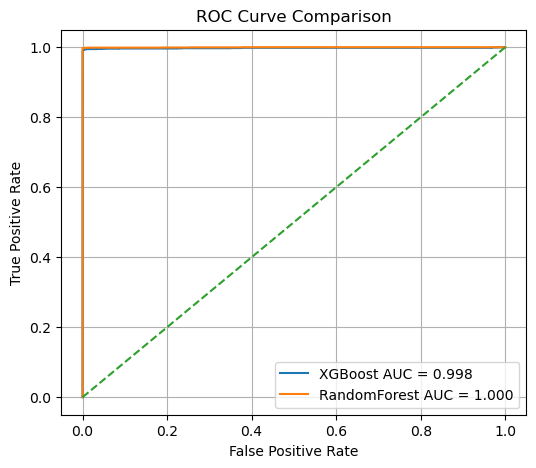

In [34]:
plt.figure(figsize=(6,5))

# XGBoost
fpr, tpr, _ = roc_curve(y_test, xgb_y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"XGBoost AUC = {roc_auc:.3f}")

# RandomForest
fpr, tpr, _ = roc_curve(y_test, rf_y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"RandomForest AUC = {roc_auc:.3f}")

# baseline
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
best_model_info = select_best_model(results)


 Best Model: RandomForest


In [36]:
threshold_result = get_optimal_threshold(y_test, rf_y_proba)
threshold_result

{'threshold': np.float64(0.7193573876778797),
 'f1': np.float64(0.9981703593292353),
 'precision': np.float64(1.0),
 'recall': np.float64(0.9963474025974026),
 'thresholds': array([0.00000000e+00, 9.51341752e-06, 9.60678177e-06, ...,
        9.99999497e-01, 9.99999574e-01, 1.00000000e+00], shape=(32643,)),
 'precision_curve': array([0.00129087, 0.00188996, 0.00189171, ..., 1.        , 1.        ,
        1.        ], shape=(32643,)),
 'recall_curve': array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        8.11688312e-03, 7.30519481e-03, 8.11688312e-04], shape=(32643,)),
 'f1_curve': array([0.00257842, 0.00377279, 0.00377628, ..., 0.01610306, 0.01450443,
        0.00162206], shape=(32643,))}

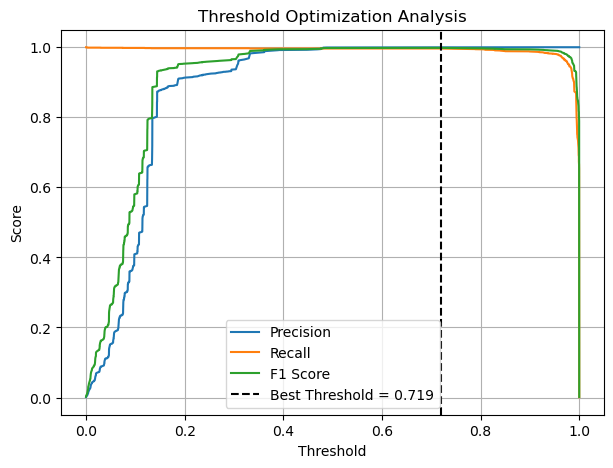

In [37]:
plot_threshold_analysis(threshold_result)

In [38]:
opt_threshold = threshold_result["threshold"]

In [39]:
rf_y_pred = (rf_y_proba >= opt_threshold).astype(int)

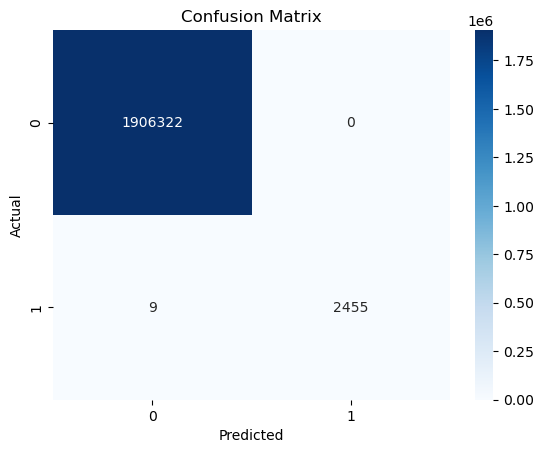

In [40]:
plot_confusion(y_test, rf_y_pred)

In [41]:
print(classification_report(y_test, rf_y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       1.00      1.00      1.00      2464

    accuracy                           1.00   1908786
   macro avg       1.00      1.00      1.00   1908786
weighted avg       1.00      1.00      1.00   1908786



In [42]:
# By optimizing the threshold, the model captures more fraudulent transactions (higher recall), 
# at the cost of increased false positives. 
# This trade-off is acceptable in fraud detection, where missing fraud is more costly than flagging legitimate transactions.

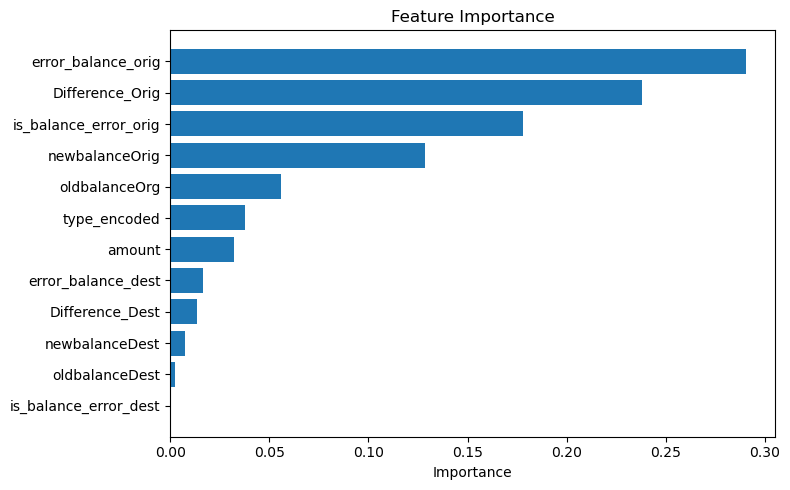

In [43]:
plot_feature_importance(
    results["RandomForest"]["model"],
    X_train.columns)

#### Save Model

In [44]:
joblib.dump(best_model_info["model"], "model.pkl")
joblib.dump(threshold_result["threshold"], "threshold.pkl")

artifact = {
    "model": best_model_info["model"],
    "threshold": threshold_result["threshold"],
    "version": "v1"}

joblib.dump(artifact, "artifact.pkl")

['artifact.pkl']

In [45]:
X_train.columns

Index(['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'Difference_Orig', 'Difference_Dest',
       'error_balance_orig', 'error_balance_dest', 'is_balance_error_orig',
       'is_balance_error_dest', 'type_encoded'],
      dtype='object')

## 6. Experiment Tracking: mlFlow logging

In [46]:
# -------------------------
# MLflow Logging
# -------------------------
# This block logs model configuration, hyperparameters, and evaluation metrics
# to MLflow for experiment tracking and reproducibility.
#
# to:
# - Keep a record of different model runs (which model, which parameters)
# - Compare performance across experiments (AUC, F1, etc.)
# - Enable reproducibility (can reload the exact model later)
# - Support basic model versioning and audit trail
#
# In short: MLflow turns model training into a trackable and comparable process

In [48]:
import mlflow
import skops

with mlflow.start_run(run_name="best_model_pipeline"):

    # model info
    mlflow.log_param("model_name", best_model_info["name"])

    # model params
    for k, v in best_model_info["model"].get_params().items():
        mlflow.log_param(k, v)

    # metrics
    mlflow.log_metric("auc", best_model_info["roc_auc"])
    mlflow.log_metric("f1", threshold_result["f1"])
    mlflow.log_metric("precision", threshold_result["precision"])
    mlflow.log_metric("recall", threshold_result["recall"])

    # threshold
    mlflow.log_param("optimal_threshold", threshold_result["threshold"])

    # model
    mlflow.sklearn.log_model(sk_model=best_model_info["model"],name="model", serialization_format="skops")

## 7. Inference System

### 7.1 Real-Time Prediction

In [49]:
best_model = best_model_info["model"]

In [50]:
X_new = X_test.iloc[:10]

### 7.2 Risk Decision Layer (ALLOW / REVIEW / BLOCK)

In [51]:
def decision(score, high=0.95, low=0.7):
    if score > high:
        return "BLOCK"
    elif score > low:
        return "REVIEW"
    else:
        return "ALLOW"

In [52]:
def predict_transaction(model, X):

    scores = model.predict_proba(X)[:, 1]
    actions = [decision(score) for score in scores]

    return [{"score": float(s),  "action": a} for s, a in zip(scores, actions)]

In [53]:
real_time_results = predict_transaction(best_model, X_new)
real_time_results

[{'score': 0.0, 'action': 'ALLOW'},
 {'score': 1.120741988708928e-05, 'action': 'ALLOW'},
 {'score': 0.0, 'action': 'ALLOW'},
 {'score': 0.0, 'action': 'ALLOW'},
 {'score': 0.003192035546180533, 'action': 'ALLOW'},
 {'score': 0.0, 'action': 'ALLOW'},
 {'score': 0.0, 'action': 'ALLOW'},
 {'score': 1.120741988708928e-05, 'action': 'ALLOW'},
 {'score': 0.0, 'action': 'ALLOW'},
 {'score': 1.120741988708928e-05, 'action': 'ALLOW'}]

## 8. Model Monitoring

### 8.1 Drift Detection(（KS test）)

In [54]:
from scipy.stats import ks_2samp

def detect_drift(train_df, new_df, features):
    
    results = {}

    for f in features:
        stat, p_value = ks_2samp(train_df[f], new_df[f])
        results[f] = {"p_value": p_value, "drift": p_value < 0.05}

    return results

In [55]:
features = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "Difference_Orig", "Difference_Dest"]

drift_results = detect_drift(X_train, X_test, features)
drift_results

# We perform drift detection only on feature distributions between training and incoming data, excluding labels to avoid target 
# leakage and ensure unbiased monitoring.

{'amount': {'p_value': np.float64(0.6777285618520728), 'drift': np.False_},
 'oldbalanceOrg': {'p_value': np.float64(0.366034432779034),
  'drift': np.False_},
 'newbalanceOrig': {'p_value': np.float64(0.4582044261341889),
  'drift': np.False_},
 'oldbalanceDest': {'p_value': np.float64(0.8972617903633655),
  'drift': np.False_},
 'newbalanceDest': {'p_value': np.float64(0.8265118857606026),
  'drift': np.False_},
 'Difference_Orig': {'p_value': np.float64(0.9934937431661446),
  'drift': np.False_},
 'Difference_Dest': {'p_value': np.float64(0.6018557605858307),
  'drift': np.False_}}

### 8.2 System Monitoring & Logging

In [ ]:
# (Implemented in FastAPI logging + Streamlit dashboard log analysis)

## 9. Model Deployment (FastAPI Service)

"""
This section defines the real-time inference service using FastAPI.
It exposes a REST API endpoint that accepts transaction data, applies feature engineering, and returns fraud probability scores
along with a final business decision (ALLOW / REVIEW / BLOCK).

In a production setup, this service is typically run in a separate terminal 
or deployed as an independent microservice (e.g., via uvicorn or Docker).

For the purpose of this project demonstration, the code is included here 
to show the complete end-to-end system architecture. However, it is not executed within this notebook environment.
"""

In [ ]:
import json
import time
import logging
import joblib
import pandas as pd

from fastapi import FastAPI
from pydantic import BaseModel
from sklearn.preprocessing import LabelEncoder

# ------------------
# Logging setup
# ------------------
logging.basicConfig(
    filename="prediction.log",
    level=logging.INFO,
    format="%(asctime)s - %(message)s")

# ------------------
# Load artifact（model + threshold + version）
# ------------------
artifact = joblib.load("artifact.pkl")

model = artifact["model"]
threshold = artifact["threshold"]
model_version = artifact.get("version", "v1")

# ------------------
# Feature engineering
# ------------------
def engineer_features(df):
    df = df.copy()

    # -----------------------------
    # Balance features
    # -----------------------------
    df["Difference_Orig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
    df["Difference_Dest"] = df["newbalanceDest"] - df["oldbalanceDest"]

    df["error_balance_orig"] = (df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"])
    df["error_balance_dest"] = (df["newbalanceDest"] - df["oldbalanceDest"] - df["amount"])

    df["is_balance_error_orig"] = (df["error_balance_orig"].abs() > 1).astype(int)
    df["is_balance_error_dest"] = (df["error_balance_dest"].abs() > 1).astype(int)

    # -----------------------------
    # Type encoding
    # -----------------------------
    df['type_encoded'] = df['type_encoded'] if 'type_encoded' in df else df['type_encoded']

    return df


# ------------------
# Feature schema
# ------------------
FEATURE_COLUMNS = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'Difference_Orig', 'Difference_Dest', 'error_balance_orig', 
       'error_balance_dest', 'is_balance_error_orig',
       'is_balance_error_dest', 'type_encoded']

# ------------------
# Business decision rule
# ------------------
def decision(score, high=0.95, low=0.7):
    if score > high:
        return "BLOCK"
    elif score > low:
        return "REVIEW"
    else:
        return "ALLOW"

# ------------------
# FastAPI app
# ------------------
app = FastAPI()

# ------------------
# Input schema
# ------------------
class Transaction(BaseModel):
    amount: float
    oldbalanceOrg: float
    newbalanceOrig: float
    oldbalanceDest: float
    newbalanceDest: float
    type_encoded: int

# ------------------
# Prediction endpoint
# ------------------
@app.post("/predict")
def predict(data: Transaction):

    # 1. input → dataframe
    df = pd.DataFrame([data.dict()])
    
    # 1. feature engineering
    df = engineer_features(df)
    df = df[FEATURE_COLUMNS]

    # 2. model inference
    score = model.predict_proba(df)[0, 1]

    # 3. threshold decision
    is_fraud = int(score >= threshold)

    # 4. business decision
    action = decision(score)

    # 5. logging
    log_record = {
        "timestamp": time.time(),
        "model_version": model_version,
        "input": data.dict(),
        "score": float(score),
        "threshold": float(threshold),
        "is_fraud": is_fraud,
        "action": action
    }

    logging.info(json.dumps(log_record))

    # 6. response
    return {
        "score": float(score),
        "is_fraud": is_fraud,
        "action": action,
        "model_version": model_version
    }

# ------------------
# Run server (Optional)
# ------------------
if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="127.0.0.1", port=8000)

## 10. Visualization & Observability

### 10.1 Streamlit Monitoring Dashboard

This module provides an observability layer for the fraud detection system. It records all prediction outputs (scores, actions, and timestamps) and visualizes them through a Streamlit dashboard. The goal is to monitor model behavior in real time, analyze score distributions, and inspect decision patterns (ALLOW / REVIEW / BLOCK). This helps ensure the system is stable, transparent, and easy to debug in a production-like environment.

In [ ]:
import streamlit as st
import pandas as pd
import json
import joblib
import matplotlib.pyplot as plt

# -------------------------
# 1. Load model / threshold
# -------------------------
model = joblib.load("model.pkl")
threshold = joblib.load("threshold.pkl")

st.title("Fraud Detection Monitoring Dashboard")


# -------------------------
# 2. Load logs
# -------------------------
def load_logs(path="prediction.log"):
    data = []

    try:
        with open(path, "r") as f:
            for line in f:
                try:
                    log = line.strip().split(" - ", 1)
                    if len(log) == 2:
                        record = json.loads(log[1])
                        data.append(record)
                except:
                    pass
    except FileNotFoundError:
        return pd.DataFrame()

    return pd.DataFrame(data)


df = load_logs()

if df.empty:
    st.warning("No log data found yet.")
    st.stop()


# -------------------------
# 3. Action mapping 
# -------------------------
def get_action(score):
    if score > 0.95:
        return "BLOCK"
    elif score > threshold:
        return "REVIEW"
    else:
        return "ALLOW"


df["action"] = df["score"].apply(get_action)


# -------------------------
# 4. Overview
# -------------------------
st.subheader("Overview")

col1, col2, col3 = st.columns(3)

col1.metric("Total Predictions", len(df))
col2.metric("Avg Score", round(df["score"].mean(), 4))
col3.metric("Fraud Rate", round((df["action"] == "BLOCK").mean(), 4))


# -------------------------
# 5. Action distribution
# -------------------------
st.subheader("Action Distribution")
st.bar_chart(df["action"].value_counts())

# -------------------------
# 6. Score distribution
# -------------------------
st.subheader("Score Distribution")
st.histogram = df["score"].hist()
st.write("Score Histogram")
st.pyplot()

# -------------------------
# 7. Score trend
# -------------------------
st.subheader("Score Trend")
st.line_chart(df["score"])


# -------------------------
# 8. Filter view
# -------------------------
st.subheader("Filtered Logs")

option = st.selectbox(
    "Filter by action",
    ["ALL", "ALLOW", "REVIEW", "BLOCK"]
)

if option != "ALL":
    filtered = df[df["action"] == option]
else:
    filtered = df

st.dataframe(filtered.tail(50))


# -------------------------
# 9. Explain decision 
# -------------------------
st.subheader("Decision Explanation (Sample)")

if len(df) > 0:
    sample = df.iloc[-1]

    st.write(f"Score: {sample['score']:.4f}")
    st.write(f"Threshold (REVIEW): {threshold}")
    st.write(f"Final Action: {sample['action']}")

    if sample["action"] == "BLOCK":
        st.error("High risk transaction detected → BLOCK")
    elif sample["action"] == "REVIEW":
        st.warning("Medium risk → requires manual review")
    else:
        st.success("Low risk → allow transaction")


# -------------------------
# 10. Raw logs
# -------------------------
st.subheader("Recent Predictions")
st.dataframe(df.tail(20))


# -------------------------
# 11. Model info
# -------------------------
st.subheader("Model Info")
st.write(f"Model: {type(model).__name__}")
st.write(f"Threshold: {threshold}")

### 10.2 Fraud Monitoring Dashboard (Observability Layer)

This Streamlit-based UI provides an interactive interface for exploring fraud detection results. It allows users to input transaction data, obtain real-time fraud predictions, and visualize model outputs such as scores, action decisions (ALLOW / REVIEW / BLOCK), and historical prediction logs. The dashboard serves as an observability and decision-support tool, enabling intuitive inspection of model behavior and system responses in a production-like environment.

In [ ]:
import streamlit as st
import joblib
import pandas as pd

# -------------------------
# Load model
# -------------------------
model = joblib.load("model.pkl")
threshold = joblib.load("threshold.pkl")

st.title("Fraud Detection System")

# -------------------------
# Feature engineering 
# -------------------------
def engineer_features(df):
    df = df.copy()

    df["Difference_Orig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
    df["Difference_Dest"] = df["newbalanceDest"] - df["oldbalanceDest"]

    df["error_balance_orig"] = (
        df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]
    )
    df["error_balance_dest"] = (
        df["newbalanceDest"] - df["oldbalanceDest"] - df["amount"]
    )

    df["is_balance_error_orig"] = (df["error_balance_orig"].abs() > 1).astype(int)
    df["is_balance_error_dest"] = (df["error_balance_dest"].abs() > 1).astype(int)

    return df


# -------------------------
# Input
# -------------------------
amount = st.number_input("Amount", 0.0)
oldbalanceOrg = st.number_input("Old Balance Org", 0.0)
newbalanceOrig = st.number_input("New Balance Orig", 0.0)
oldbalanceDest = st.number_input("Old Balance Dest", 0.0)
newbalanceDest = st.number_input("New Balance Dest", 0.0)
type_encoded = st.selectbox("Type", [0, 1, 2, 3, 4])


# -------------------------
# Predict
# -------------------------
if st.button("Predict"):

    # raw input
    data = pd.DataFrame([{
        "amount": amount,
        "oldbalanceOrg": oldbalanceOrg,
        "newbalanceOrig": newbalanceOrig,
        "oldbalanceDest": oldbalanceDest,
        "newbalanceDest": newbalanceDest,
        "type_encoded": type_encoded
    }])

    # feature engineering
    data = engineer_features(data)

    # ensure correct order
    FEATURE_COLUMNS = [
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest",
        "Difference_Orig",
        "Difference_Dest",
        "error_balance_orig",
        "error_balance_dest",
        "is_balance_error_orig",
        "is_balance_error_dest",
        "type_encoded"
    ]

    data = data[FEATURE_COLUMNS]

    # prediction
    score = model.predict_proba(data)[0, 1]

    # decision
    if score >= threshold:
        label = "FRAUD"
    else:
        label = "NORMAL"

    # -------------------------
    # Output
    # -------------------------
    st.subheader("Result")

    st.write(f"Score: {score:.4f}")
    st.write(f"Threshold: {threshold:.4f}")

    if label == "FRAUD":
        st.error("FRAUD")
    else:
        st.success("NORMAL")